In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nguyenhung1903/nerf-synthetic-dataset/nerf_synthetic/README.txt
/kaggle/input/datasets/nguyenhung1903/nerf-synthetic-dataset/nerf_synthetic/ship/transforms_test.json
/kaggle/input/datasets/nguyenhung1903/nerf-synthetic-dataset/nerf_synthetic/ship/transforms_train.json
/kaggle/input/datasets/nguyenhung1903/nerf-synthetic-dataset/nerf_synthetic/ship/transforms_val.json
/kaggle/input/datasets/nguyenhung1903/nerf-synthetic-dataset/nerf_synthetic/ship/val/r_13.png
/kaggle/input/datasets/nguyenhung1903/nerf-synthetic-dataset/nerf_synthetic/ship/val/r_50.png
/kaggle/input/datasets/nguyenhung1903/nerf-synthetic-dataset/nerf_synthetic/ship/val/r_11.png
/kaggle/input/datasets/nguyenhung1903/nerf-synthetic-dataset/nerf_synthetic/ship/val/r_20.png
/kaggle/input/datasets/nguyenhung1903/nerf-synthetic-dataset/nerf_synthetic/ship/val/r_33.png
/kaggle/input/datasets/nguyenhung1903/nerf-synthetic-dataset/nerf_synthetic/ship/val/r_42.png
/kaggle/input/datasets/nguyenhung1903/nerf-

dict_keys(['camera_angle_x', 'frames'])
Number of images: 100
Image shape: (800, 800, 4)
Pose shape: (4, 4)
Focal length: 1111.1110311937682


/tmp/ipykernel_132/330742942.py:21: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(img_path)


Points shape: torch.Size([640000, 64, 3])
Sample point: tensor([0.6958, 1.7319, 1.2956])
torch.Size([40960000, 63])
tensor([ 0.6958,  1.7319,  1.2956,  0.6410,  0.9871,  0.9624,  0.7675, -0.1604,
         0.2717,  0.9840, -0.3167,  0.5230,  0.1782, -0.9485, -0.8523,  0.3506,
         0.6007, -0.8915, -0.9365,  0.7995,  0.4529, -0.6567,  0.9605, -0.8076,
         0.7541,  0.2782, -0.5897, -0.9905,  0.5345,  0.9525,  0.1374, -0.8452,
        -0.3045, -0.2723, -0.9035, -0.5801, -0.9622,  0.4286, -0.8145,  0.5240,
        -0.7745,  0.9451,  0.8517, -0.6326,  0.3269,  0.8926,  0.9799,  0.6178,
         0.4509, -0.1996, -0.7863,  0.8049, -0.3912, -0.9716, -0.5935, -0.9203,
         0.2365, -0.9553,  0.7201, -0.4596, -0.2956,  0.6939, -0.8881])
torch.Size([65536, 3]) torch.Size([65536, 1])
torch.Size([1024, 3])
Step 0, Loss: 0.028395667672157288
Step 50, Loss: 0.008794257417321205
Step 100, Loss: 0.006543554365634918
Step 150, Loss: 0.005491370335221291
Step 200, Loss: 0.0045477766543626785
S

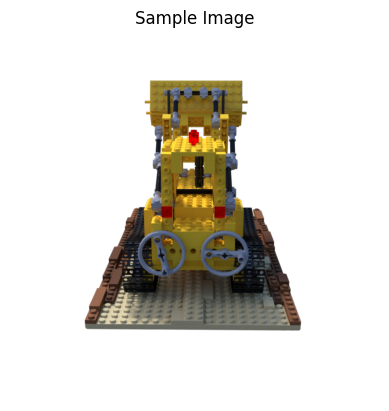

In [37]:
import json
import os

base_path = "/kaggle/input/datasets/nguyenhung1903/nerf-synthetic-dataset/nerf_synthetic/lego" 
with open(os.path.join(base_path, "transforms_train.json")) as f:
    meta = json.load(f)

print(meta.keys())

camera_angle_x = meta["camera_angle_x"]
frames = meta["frames"]

print("Number of images:", len(frames))

import imageio
import numpy as np

frame = frames[0]

img_path = os.path.join(base_path, frame["file_path"] + ".png")
image = imageio.imread(img_path)

pose = np.array(frame["transform_matrix"])

print("Image shape:", image.shape)
print("Pose shape:", pose.shape)

H, W = image.shape[:2]

focal = 0.5 * W / np.tan(0.5 * camera_angle_x)

print("Focal length:", focal)

import matplotlib.pyplot as plt

plt.imshow(image)
plt.title("Sample Image")
plt.axis("off")

image = image[..., :3] / 255.0  # keep RGB + normalize

import torch

H, W = image.shape[:2]

i, j = torch.meshgrid(
    torch.arange(W),
    torch.arange(H),
    indexing='xy'
)

i = i.float()
j = j.float()

x = (i - W/2) / focal
y = -(j - H/2) / focal
z = -1

dirs = torch.stack([
    (i - W * 0.5) / focal,
    -(j - H * 0.5) / focal,
    -torch.ones_like(i)
], dim=-1)

c2w = torch.tensor(pose).float()

rays_d = torch.sum(dirs[..., None, :] * c2w[:3, :3], dim=-1)
rays_o = c2w[:3, -1].expand(rays_d.shape)

rays_o = rays_o.reshape(-1, 3)
rays_d = rays_d.reshape(-1, 3)

pixels = torch.tensor(image.reshape(-1, 3)).float()

near = 2.0
far = 6.0

N_samples = 64

t_vals = torch.linspace(near, far, N_samples)

t_vals = t_vals.expand(rays_o.shape[0], N_samples)

pts = rays_o[:, None, :] + rays_d[:, None, :] * t_vals[..., None]

print("Points shape:", pts.shape)
print("Sample point:", pts[0, 0])

def positional_encoding(x, L=10):
    """
    x: (..., 3)
    returns: (..., 3 * (2L + 1))
    """
    encodings = [x]
    
    for i in range(L):
        for fn in [torch.sin, torch.cos]:
            encodings.append(fn((2.0 ** i) * x))
    
    return torch.cat(encodings, dim=-1)


pts_flat = pts.reshape(-1, 3)

encoded_pts = positional_encoding(pts_flat)

print(encoded_pts.shape)

print(encoded_pts[0])

N_rand = 1024


select_inds = torch.randperm(rays_o.shape[0])[:N_rand]

rays_o_batch = rays_o[select_inds]
rays_d_batch = rays_d[select_inds]
pixels_batch = pixels[select_inds]

t_vals = torch.linspace(2.0, 6.0, 64)
t_vals = t_vals.expand(N_rand, 64)

pts = rays_o_batch[:, None, :] + rays_d_batch[:, None, :] * t_vals[..., None]

pts_flat = pts.reshape(-1, 3)
encoded_pts = positional_encoding(pts_flat)

import torch.nn as nn
import torch.nn.functional as F

class NeRF(nn.Module):
    def __init__(self, input_dim=63):
        super().__init__()
        
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 256)
        self.fc4 = nn.Linear(256, 256)

        # Skip connection
        self.fc5 = nn.Linear(256 + input_dim, 256)

        self.fc6 = nn.Linear(256, 256)
        self.fc7 = nn.Linear(256, 256)

        # Outputs
        self.sigma = nn.Linear(256, 1)
        self.rgb = nn.Linear(256, 3)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        h = F.relu(self.fc3(h))
        h = F.relu(self.fc4(h))

        # Skip connection
        h = torch.cat([h, x], dim=-1)
        h = F.relu(self.fc5(h))

        h = F.relu(self.fc6(h))
        h = F.relu(self.fc7(h))

        sigma = self.sigma(h)
        rgb = torch.sigmoid(self.rgb(h))

        return rgb, sigma

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = NeRF().to(DEVICE)
out_rgb, out_sigma = model(encoded_pts.to(DEVICE))
print(out_rgb.shape, out_sigma.shape)

rgb = out_rgb.reshape(N_rand, 64, 3)
sigma = out_sigma.reshape(N_rand, 64)

t_vals = t_vals.to(DEVICE)

dists = t_vals[:, 1:] - t_vals[:, :-1]
dists = torch.cat([
    dists,
    torch.tensor([1e10], device=DEVICE).expand(dists[:, :1].shape)
], dim=-1)

alpha = 1.0 - torch.exp(-sigma * dists)

T = torch.cumprod(
    torch.cat([
        torch.ones((alpha.shape[0], 1), device=DEVICE),
        1. - alpha + 1e-10
    ], dim=-1),
    dim=-1
)[:, :-1]

weights = alpha * T

rgb_map = torch.sum(weights[..., None] * rgb, dim=1)

print(rgb_map.shape)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)


for step in range(1000):
    
    # 1. Sample random rays
    select_inds = torch.randperm(rays_o.shape[0])[:N_rand]
    
    rays_o_batch = rays_o[select_inds].to(DEVICE)
    rays_d_batch = rays_d[select_inds].to(DEVICE)
    target = pixels[select_inds].to(DEVICE)

    # 2. Sample points (CREATE DIRECTLY ON DEVICE)
    t_vals = torch.linspace(2.0, 6.0, 64, device=DEVICE)
    t_vals = t_vals.expand(N_rand, 64)

    pts = rays_o_batch[:, None, :] + rays_d_batch[:, None, :] * t_vals[..., None]

    # 3. Encode
    pts_flat = pts.reshape(-1, 3)
    encoded_pts = positional_encoding(pts_flat).to(DEVICE)

    # 4. Predict
    rgb, sigma = model(encoded_pts)
    
    # 🔥 MUST reshape BEFORE anything else
    rgb = rgb.reshape(N_rand, 64, 3)
    sigma = sigma.reshape(N_rand, 64)
    
    # Then apply relu/clamp
    sigma = torch.relu(sigma)
    sigma = torch.clamp(sigma, 0.0, 10.0)
    
    dists = t_vals[:, 1:] - t_vals[:, :-1]
    dists = torch.cat([
        dists,
        torch.tensor([1.0], device=DEVICE).expand(dists[:, :1].shape)
    ], dim=-1)
    
    alpha = 1.0 - torch.exp(-sigma * dists)
    alpha = torch.clamp(alpha, 0.0, 1.0)
    alpha = torch.nan_to_num(alpha)
    
    T = torch.cumprod(
        torch.cat([
            torch.ones((alpha.shape[0], 1), device=DEVICE),
            1. - alpha + 1e-6
        ], dim=-1),
        dim=-1
    )[:, :-1]
    
    T = torch.clamp(T, 0.0, 1.0)
    T = torch.nan_to_num(T)
    
    weights = alpha * T
    rgb_map = torch.sum(weights[..., None] * rgb, dim=1)
    # 7. Loss
    loss = torch.mean((rgb_map - target) ** 2)

    # 8. Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"Step {step}, Loss: {loss.item()}")



In [38]:
rays_o_full = rays_o.to(DEVICE)
rays_d_full = rays_d.to(DEVICE)

In [39]:
chunk = 4096
rgb_chunks = []

for i in range(0, rays_o_full.shape[0], chunk):
    
    rays_o_batch = rays_o_full[i:i+chunk]
    rays_d_batch = rays_d_full[i:i+chunk]

    # Normalize directions
    rays_d_batch = rays_d_batch / torch.norm(rays_d_batch, dim=-1, keepdim=True)

    # Sample points
    t_vals = torch.linspace(2.0, 6.0, 64, device=DEVICE)
    t_vals = t_vals.expand(rays_o_batch.shape[0], 64)

    pts = rays_o_batch[:, None, :] + rays_d_batch[:, None, :] * t_vals[..., None]

    # Encode
    pts_flat = pts.reshape(-1, 3)
    encoded = positional_encoding(pts_flat).to(DEVICE)

    # Predict
    rgb, sigma = model(encoded)

    rgb = rgb.reshape(rays_o_batch.shape[0], 64, 3)
    sigma = sigma.reshape(rays_o_batch.shape[0], 64)

    sigma = torch.relu(sigma)
    sigma = torch.clamp(sigma, 0.0, 10.0)

    # Volume rendering
    dists = t_vals[:, 1:] - t_vals[:, :-1]
    dists = torch.cat([
        dists,
        torch.tensor([1.0], device=DEVICE).expand(dists[:, :1].shape)
    ], dim=-1)

    alpha = 1.0 - torch.exp(-sigma * dists)
    alpha = torch.clamp(alpha, 0.0, 1.0)

    T = torch.cumprod(
        torch.cat([
            torch.ones((alpha.shape[0], 1), device=DEVICE),
            1. - alpha + 1e-6
        ], dim=-1),
        dim=-1
    )[:, :-1]

    weights = alpha * T
    rgb_map = torch.sum(weights[..., None] * rgb, dim=1)

    rgb_chunks.append(rgb_map.detach().cpu())

(np.float64(-0.5), np.float64(799.5), np.float64(799.5), np.float64(-0.5))

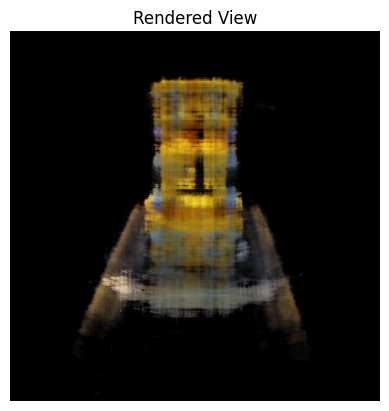

In [43]:
import torch

rgb_final = torch.cat(rgb_chunks, dim=0)

image = rgb_final.reshape(H, W, 3).numpy()
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title("Rendered View")
plt.axis("off")